In [11]:
print("helloworld")

helloworld


In [10]:
import numpy as np
import matplotlib.pyplot as plt


Implementation of the superfermion representation matrix of single mode fermion

In [12]:
def superfermion_operators():
    I = np.eye(2, dtype=complex)

    sm = np.array([[0, 1],
                   [0, 0]], dtype=complex)
    sp = sm.conj().T
    sz = np.array([[1, 0],
                   [0, -1]], dtype=complex)

    # first fermionic mode: physical c
    c = np.kron(sm, I)
    cd = c.conj().T

    # second fermionic mode: tilde c
    ct = np.kron(sz, sm)
    ctd = ct.conj().T

    return c, cd, ct, ctd, np.eye(4, dtype=complex)

def rosso_eq39_matrix(eps, Gamma1, Gamma2, hbar=1.0):
    c, cd, ct, ctd, I4 = superfermion_operators()

    n = cd @ c
    nt = ctd @ ct

    L = (
        eps * (n - nt)
        - 0.5j * hbar * (Gamma1 - Gamma2) * (n + nt)
        + hbar * (Gamma1 * (c @ ct) + Gamma2 * (cd @ ctd))
        - 1j * hbar * Gamma2 * I4
    )

    return L

def analytic_rosso_eigenvalues(eps, Gamma1, Gamma2, hbar=1.0):
    G = Gamma1 + Gamma2
    return np.array([
        0.0,
        -1j * hbar * G,
        eps - 0.5j * hbar * G,
        -eps - 0.5j * hbar * G,
    ], dtype=complex)

eps = 1.3
Gamma1 = 0.7
Gamma2 = 0.2
hbar = 1.0

L = rosso_eq39_matrix(eps, Gamma1, Gamma2, hbar=hbar)

num = np.linalg.eigvals(L)
ana = analytic_rosso_eigenvalues(eps, Gamma1, Gamma2, hbar=hbar)

print("Numerical:")
print(np.sort_complex(num))

print("\nAnalytic:")
print(np.sort_complex(ana))

Numerical:
[-1.30000000e+00-4.50000000e-01j  0.00000000e+00+3.12250226e-17j
  2.77555756e-17-9.00000000e-01j  1.30000000e+00-4.50000000e-01j]

Analytic:
[-1.3-0.45j  0. -0.9j   0. +0.j    1.3-0.45j]


Reimplementing the code for full numerical treatment of random matrices

In [13]:
def split_diagonal_offdiagonal(matrix: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Split a matrix A into:
        D = diagonal part
        V = off-diagonal part
    so that A = D + V
    """
    if matrix.ndim != 2 or matrix.shape[0] != matrix.shape[1]:
        raise ValueError("matrix must be a square 2D array")

    D = np.diag(np.diag(matrix))
    V = matrix - D
    return D, V


def drop_small_offdiagonals(
    matrix: np.ndarray,
    original_matrix: np.ndarray,
    threshold: float = 0.01,
    atol: float = 0.0
) -> np.ndarray:
    """
    Zero out off-diagonal entries of `matrix` if

        |matrix[i,j]| < threshold * |original_matrix[i,j]|

    or, additionally, if

        |matrix[i,j]| < atol

    Diagonal entries are left unchanged.
    """
    if matrix.shape != original_matrix.shape:
        raise ValueError("matrix and original_matrix must have the same shape")

    if matrix.ndim != 2 or matrix.shape[0] != matrix.shape[1]:
        raise ValueError("matrix and original_matrix must be square 2D arrays")

    result = matrix.copy()
    n = matrix.shape[0]

    for i in range(n):
        for j in range(n):
            if i != j:
                if (
                    np.abs(result[i, j]) < threshold * np.abs(original_matrix[i, j])
                    or np.abs(result[i, j]) < atol
                ):
                    result[i, j] = 0.0

    return result


def commutator(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    return A @ B - B @ A


def split_diagonal_offdiagonal(matrix: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    A = D + V
    D: diagonal part
    V: off-diagonal part
    """
    if matrix.ndim != 2 or matrix.shape[0] != matrix.shape[1]:
        raise ValueError("matrix must be a square 2D array")

    D = np.diag(np.diag(matrix))
    V = matrix - D
    return D, V


def eta_first(A: np.ndarray) -> np.ndarray:
    """
    First Rosso generator:
        eta_1 = [A^\dagger, V]
    """
    _, V = split_diagonal_offdiagonal(A)
    return commutator(A.conj().T, V)


def eta_second(A: np.ndarray) -> np.ndarray:
    """
    Second Rosso generator:
        eta_2 = [D^\dagger, V]
    """
    D, V = split_diagonal_offdiagonal(A)
    return commutator(D.conj().T, V)


def eta_third(A: np.ndarray, eps: float = 1e-14) -> np.ndarray:
    """
    Third Rosso/White-like generator:
        eta_3[n,k] = V[n,k] / (D[n,n] - D[k,k])   if denominator != 0
                   = 0                            otherwise

    The diagonal is zero automatically because V has zero diagonal.
    """
    D, V = split_diagonal_offdiagonal(A)
    diag = np.diag(D)
    n = A.shape[0]

    eta = np.zeros_like(A, dtype=np.complex128)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue

            denom = diag[i] - diag[j]
            if np.abs(denom) > eps:
                eta[i, j] = V[i, j] / denom
            else:
                eta[i, j] = 0.0

    return eta


def get_eta(A: np.ndarray, generator: str = "first", eps: float = 1e-14) -> np.ndarray:
    """
    Dispatch function for generator choice.

    Allowed values:
        'first'  -> eta_1 = [A^\dagger, V]
        'second' -> eta_2 = [D^\dagger, V]
        'third'  -> eta_3[n,k] = V[n,k] / (D_nn - D_kk)
    """
    generator = generator.lower()

    if generator == "first":
        return eta_first(A)
    elif generator == "second":
        return eta_second(A)
    elif generator == "third":
        return eta_third(A, eps=eps)
    else:
        raise ValueError(
            "Unknown generator. Choose from {'first', 'second', 'third'}."
        )


def flow_rhs(A: np.ndarray, generator: str = "first", eps: float = 1e-14) -> np.ndarray:
    """
    Flow equation RHS:
        dA/dl = [eta(A), A]
    """
    eta = get_eta(A, generator=generator, eps=eps)
    return commutator(eta, A)


def rk4_step(f, y: np.ndarray, h: float, **f_kwargs) -> np.ndarray:
    k1 = f(y, **f_kwargs)
    k2 = f(y + 0.5 * h * k1, **f_kwargs)
    k3 = f(y + 0.5 * h * k2, **f_kwargs)
    k4 = f(y + h * k3, **f_kwargs)

    return y + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

def initialize_diagonal_tracker(n: int) -> dict:
    """
    Create a container to store the flow of diagonal entries.

    Parameters
    ----------
    n : int
        Matrix dimension.

    Returns
    -------
    dict
        Tracker dictionary for storing flow data.
    """
    return {
        "l_values": [],
        "diag_real": [[] for _ in range(n)],
        "diag_imag": [[] for _ in range(n)],
    }


def record_diagonal_step(tracker: dict, A: np.ndarray, l: float) -> None:
    """
    Record the diagonal entries of the current matrix A at flow parameter l.

    Parameters
    ----------
    tracker : dict
        Tracker created by initialize_diagonal_tracker.
    A : np.ndarray
        Current matrix.
    l : float
        Current flow parameter.
    """
    diag = np.diag(A)
    tracker["l_values"].append(l)

    for i, val in enumerate(diag):
        tracker["diag_real"][i].append(val.real)
        tracker["diag_imag"][i].append(val.imag)


def plot_diagonal_flow(tracker: dict,
                       figsize: tuple[float, float] = (8, 6),
                       show_legend: bool = False,
                       title_prefix: str = "Diagonal flow") -> None:
    """
    Plot the real and imaginary parts of the diagonal entries in two separate plots.

    Parameters
    ----------
    tracker : dict
        Tracker containing recorded diagonal flow data.
    figsize : tuple
        Figure size for each plot.
    show_legend : bool
        Whether to show a legend for each diagonal element.
    title_prefix : str
        Prefix for plot titles.
    """
    l_values = np.array(tracker["l_values"])
    diag_real = tracker["diag_real"]
    diag_imag = tracker["diag_imag"]

    # Plot real parts
    plt.figure(figsize=figsize)
    for i, y in enumerate(diag_real):
        label = rf"$\mathrm{{Re}}\,A_{{{i+1}{i+1}}}$" if show_legend else None
        plt.plot(l_values, y, label=label)
    plt.xlabel(r"$\ell$")
    plt.ylabel("Real part of diagonal entries")
    plt.title(f"{title_prefix}: real parts")
    if show_legend:
        plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

    # Plot imaginary parts
    plt.figure(figsize=figsize)
    for i, y in enumerate(diag_imag):
        label = rf"$\mathrm{{Im}}\,A_{{{i+1}{i+1}}}$" if show_legend else None
        plt.plot(l_values, y, label=label)
    plt.xlabel(r"$\ell$")
    plt.ylabel("Imaginary part of diagonal entries")
    plt.title(f"{title_prefix}: imaginary parts")
    if show_legend:
        plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

def solve_flow_rk4(
    A0: np.ndarray,
    dl: float = 1e-3,
    n_steps: int = 15000,
    threshold: float = 0.01,
    atol_drop: float = 0.0,
    generator: str = "first",
    eta_eps: float = 1e-14,
    track_diagonal: bool = False
):
    A = A0.astype(np.complex128).copy()
    A_initial = A.copy()

    tracker = initialize_diagonal_tracker(A.shape[0]) if track_diagonal else None
    if track_diagonal:
        record_diagonal_step(tracker, A, l=0.0)

    for step in range(n_steps):
        A = rk4_step(
            flow_rhs,
            A,
            dl,
            generator=generator,
            eps=eta_eps
        )

        A = drop_small_offdiagonals(
            A,
            A_initial,
            threshold=threshold,
            atol=atol_drop
        )

        if track_diagonal:
            current_l = (step + 1) * dl
            record_diagonal_step(tracker, A, l=current_l)

    return A, tracker

running the full numerical tracking vs np solve vs analytic 

In [14]:
L_first, tracker_first = solve_flow_rk4(
    L,
    generator="first",
    track_diagonal=True
)

L_second, tracker_second = solve_flow_rk4(
    L,
    generator="second",
    track_diagonal=True
)

L_third, tracker_third = solve_flow_rk4(
    L,
    generator="third",
    track_diagonal=True
)
#plot_diagonal_flow(tracker_first, title_prefix="First generator")
#plot_diagonal_flow(tracker_second, title_prefix="Second generator")
#plot_diagonal_flow(tracker_third, title_prefix="Third generator")

Note to self, due to the way that rosso uses the superfermion representation, his eigenvalues switch real and imaginary parts, which can cause confusion


In [15]:
print(np.diag(L_first))
print(np.diag(L_second))
print(np.diag(L_third))

[ 0. -3.84732539e-05j -1.3-4.50000000e-01j  1.3-4.50000000e-01j
  0. -8.99961527e-01j]
[ 0. -1.55310272e-05j -1.3-4.50000000e-01j  1.3-4.50000000e-01j
  0. -8.99984469e-01j]
[ 0. -1.55300285e-05j -1.3-4.50000000e-01j  1.3-4.50000000e-01j
  0. -8.99984470e-01j]


Trying to reproduce the Dissipative scatterig model

In [16]:
def quadratic_fermion_H_ordered(N, v=1.0, L=2*np.pi, hbar=1.0):
    """
    Single-particle coefficient matrix H for

        H_hat = sum_n epsilon_n c_n^\dagger c_n

    with linear dispersion epsilon_n = hbar*v*(2*pi/L)*n.

    N: cutoff, modes n=-N,...,N
    returns H, ns, eps
    """
    ns = np.arange(-N, N + 1)
    eps = hbar * v * (2*np.pi / L) * ns

    H = np.diag(eps.astype(complex))
    return H, ns, eps


def Mprime_ordered_scattering(N, gamma, v=1.0, L=2*np.pi, hbar=1.0):
    """
    First block M' = H - i*hbar/2 * Lambda_1
    for the ordered dissipative scattering model.
    """
    H, ns, eps = quadratic_fermion_H_ordered(N, v=v, L=L, hbar=hbar)

    D = 2*N + 1
    Lambda1 = (hbar * gamma / L) * np.ones((D, D), dtype=complex)

    Mprime = H - 0.5j * hbar * Lambda1
    return Mprime, H, ns, eps

Brute force implementation where each commutator is calculated explicitly (which is admittedly stupid snce it adds unnecessary computational cost)

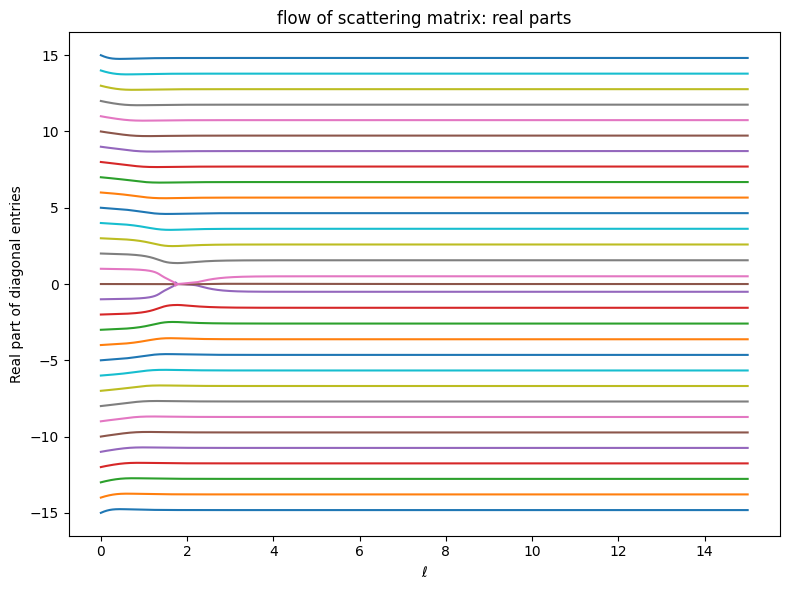

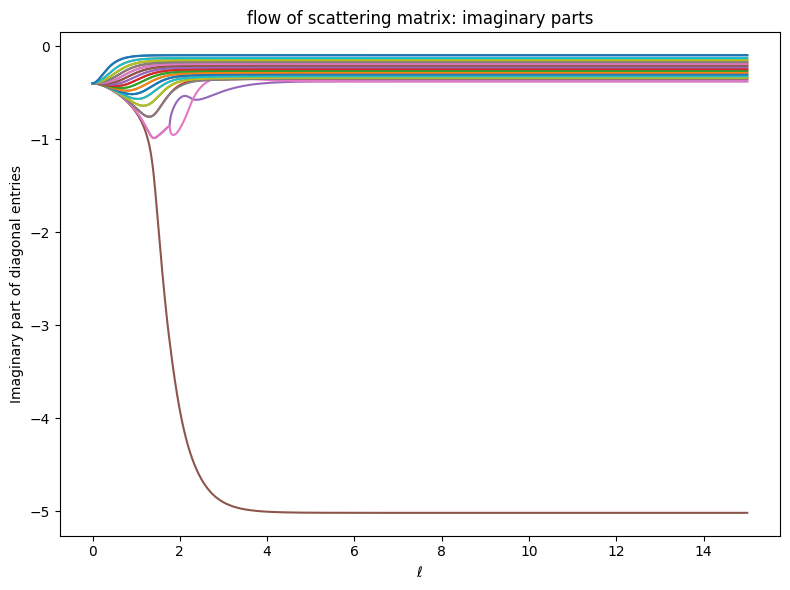

In [17]:
"""
Implementing the matrix flow from rosso with v=1, j = 15, gamma=5
    
"""
N = 15
gamma = 5.0

M, H, ns, eps = Mprime_ordered_scattering(N, gamma)

Scatering_M, tracker_third_scattering = solve_flow_rk4(
    M,
    generator="third",
    track_diagonal=True
)


plot_diagonal_flow(tracker_third_scattering, title_prefix="flow of scattering matrix")

In [20]:
def kron(a, b):
    return np.kron(a, b)

def liouvillian_sa_convention(H, jumps):
    """
    Sá-Ribeiro-Prosen / doubled-Hilbert-space convention.

    Vectorization:
        |rho>> = sum_ij rho_ij |i> tensor |j>*.

    Mapping:
        A rho B^\dagger -> (A tensor B*) |rho>>

    Lindblad convention used here:
        d rho / dt = -i[H,rho] 
                   + sum_j (J rho J^\dagger - 1/2 {J^\dagger J, rho})
    """
    d = H.shape[0]
    I = np.eye(d, dtype=complex)

    Lmat = -1j * (kron(H, I) - kron(I, H.conj()))

    for J in jumps:
        JdagJ = J.conj().T @ J

        Lmat += (
            kron(J, J.conj())
            - 0.5 * kron(JdagJ, I)
            - 0.5 * kron(I, JdagJ.conj())
        )

    return Lmat

def open_dicke_4d_sa(
    wc=1.0,
    w0=1.0,
    g=0.2,
    kappa=0.1,
    gamma=0.0,
    gamma_phi=0.0,
    model="rabi",
):
    """
    Basis:
        |0,dn>, |0,up>, |1,dn>, |1,up>

    Hilbert space:
        photon cutoff n=0,1 tensor spin-1/2
    """

    Iph = np.eye(2, dtype=complex)
    Is = np.eye(2, dtype=complex)

    a_ph = np.array([[0, 1],
                     [0, 0]], dtype=complex)
    adag_ph = a_ph.conj().T
    n_ph = adag_ph @ a_ph

    sx = np.array([[0, 1],
                   [1, 0]], dtype=complex)
    sz = np.array([[-1, 0],
                   [0,  1]], dtype=complex)

    # spin basis: |dn>, |up>
    sp = np.array([[0, 0],
                   [1, 0]], dtype=complex)  # |up><dn|
    sm = np.array([[0, 1],
                   [0, 0]], dtype=complex)  # |dn><up|

    a = kron(a_ph, Is)
    adag = kron(adag_ph, Is)
    n = kron(n_ph, Is)

    Sx = kron(Iph, sx)
    Sz = kron(Iph, sz)
    Sp = kron(Iph, sp)
    Sm = kron(Iph, sm)

    H0 = wc * n + 0.5 * w0 * Sz

    if model == "rabi":
        H_int = g * (a + adag) @ Sx
    elif model == "jc":
        H_int = g * (adag @ Sm + a @ Sp)
    else:
        raise ValueError("model must be 'rabi' or 'jc'")

    H = H0 + H_int

    jumps = []

    if kappa != 0:
        jumps.append(np.sqrt(kappa) * a)

    if gamma != 0:
        jumps.append(np.sqrt(gamma) * Sm)

    if gamma_phi != 0:
        jumps.append(np.sqrt(gamma_phi) * Sz)

    Lmat = liouvillian_sa_convention(H, jumps)


    # dissipators
    for J in jumps:
        JdagJ = J.conj().T @ J
        Lmat += (
            kron(J.conj(), J)
            - 0.5 * kron(np.eye(4, dtype=complex), JdagJ)
            - 0.5 * kron(JdagJ.T, np.eye(4, dtype=complex))
        )

    return Lmat, H, jumps

def check_liouvillian_action(H, jumps):
    d = H.shape[0]
    Lmat = liouvillian_sa_convention(H, jumps)

    # random test density matrix, not necessarily physical
    rho = np.random.randn(d, d) + 1j * np.random.randn(d, d)

    rho_dot_direct = -1j * (H @ rho - rho @ H)

    for J in jumps:
        JdagJ = J.conj().T @ J
        rho_dot_direct += (
            J @ rho @ J.conj().T
            - 0.5 * (JdagJ @ rho + rho @ JdagJ)
        )

    rho_dot_vec = Lmat @ rho.reshape(-1, order="C")
    rho_dot_matrix = rho_dot_vec.reshape((d, d), order="C")

    return np.linalg.norm(rho_dot_direct - rho_dot_matrix)


In [21]:
Dicke_L, H_L, jumps_L = open_dicke_4d_sa()
print(check_liouvillian_action(H_L, jumps_L))

5.51652975463278e-16


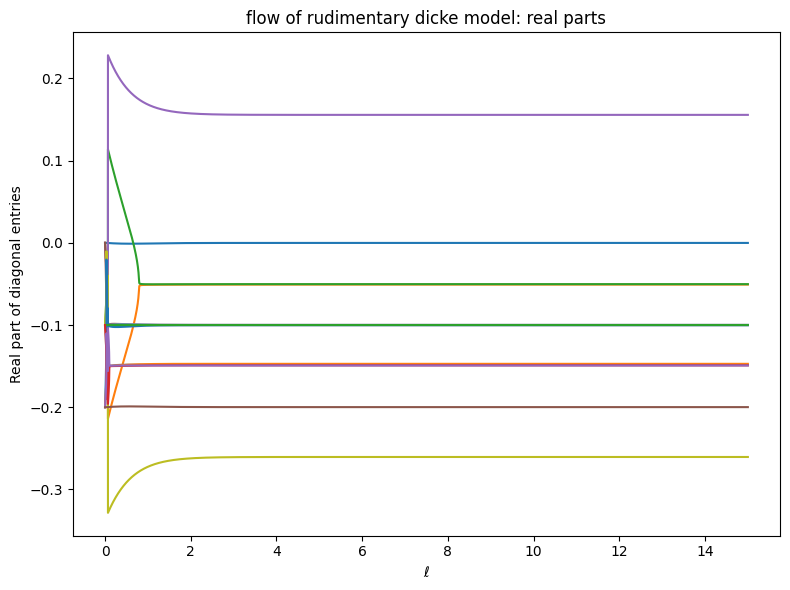

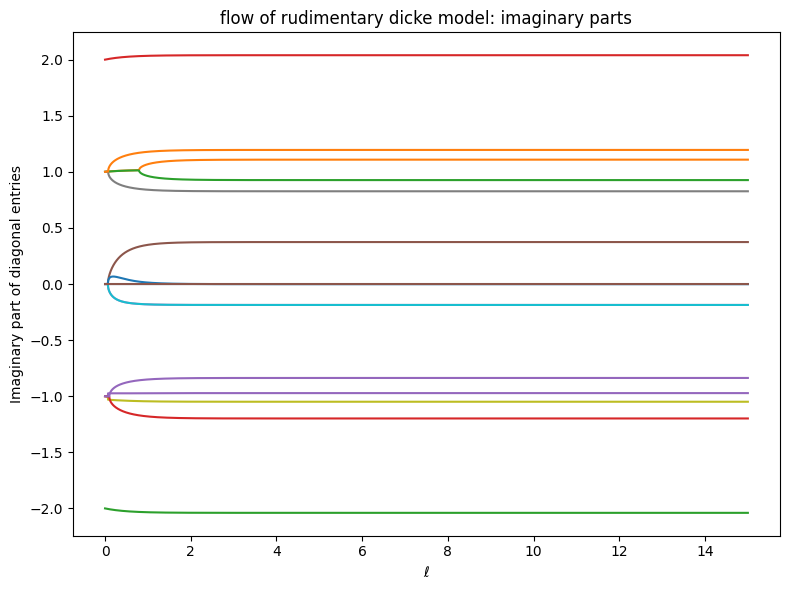

In [22]:
Scatering_dicke, tracker_dicke = solve_flow_rk4(
    Dicke_L,
    generator="third",
    track_diagonal=True
)


plot_diagonal_flow(tracker_dicke, title_prefix="flow of rudimentary dicke model")

Trying to extend to a larger dicke model

In [8]:
from scipy.linalg import eig


# ============================================================
# Basic local operators
# ============================================================

def photon_ops(n_max: int):
    """
    Photon annihilation, creation, number, identity
    for truncated Fock space n = 0, ..., n_max.
    """
    d_ph = n_max + 1

    a = np.zeros((d_ph, d_ph), dtype=complex)

    for n in range(1, d_ph):
        a[n - 1, n] = np.sqrt(n)

    adag = a.conj().T
    num = adag @ a
    I = np.eye(d_ph, dtype=complex)

    return a, adag, num, I


def spin_ops():
    """
    Spin-1/2 Pauli operators and ladder operators.
    Basis convention:
        |up>   = [1, 0]
        |down> = [0, 1]
    """
    sx = np.array([[0, 1],
                   [1, 0]], dtype=complex)

    sy = np.array([[0, -1j],
                   [1j, 0]], dtype=complex)

    sz = np.array([[1, 0],
                   [0, -1]], dtype=complex)

    sp = np.array([[0, 1],
                   [0, 0]], dtype=complex)   # |up><down|

    sm = np.array([[0, 0],
                   [1, 0]], dtype=complex)   # |down><up|

    I = np.eye(2, dtype=complex)

    return sx, sy, sz, sp, sm, I


# ============================================================
# Tensor product embedding
# Hilbert space ordering:
#       photon ⊗ spin1 ⊗ spin2
# ============================================================

def embed_photon(op_ph, I_s):
    return kron(kron(op_ph, I_s), I_s)


def embed_spin1(I_ph, op_s, I_s):
    return kron(kron(I_ph, op_s), I_s)


def embed_spin2(I_ph, I_s, op_s):
    return kron(kron(I_ph, I_s), op_s)


def build_basis(n_max: int):
    """
    Returns a list of basis labels in the ordering used by kron:
        |n, s1, s2>
    with s = +1 for up, -1 for down.
    """
    basis = []

    for n in range(n_max + 1):
        for s1 in [+1, -1]:
            for s2 in [+1, -1]:
                basis.append((n, s1, s2))

    return basis


# ============================================================
# Full Hilbert-space operators
# ============================================================

def build_full_operators(n_max: int = 2):
    a_ph, adag_ph, num_ph, I_ph = photon_ops(n_max)
    sx, sy, sz, sp, sm, I_s = spin_ops()

    ops = {}

    # photon operators
    ops["a"] = embed_photon(a_ph, I_s)
    ops["adag"] = embed_photon(adag_ph, I_s)
    ops["n"] = embed_photon(num_ph, I_s)

    # spin 1 operators
    ops["sx1"] = embed_spin1(I_ph, sx, I_s)
    ops["sy1"] = embed_spin1(I_ph, sy, I_s)
    ops["sz1"] = embed_spin1(I_ph, sz, I_s)
    ops["sp1"] = embed_spin1(I_ph, sp, I_s)
    ops["sm1"] = embed_spin1(I_ph, sm, I_s)

    # spin 2 operators
    ops["sx2"] = embed_spin2(I_ph, I_s, sx)
    ops["sy2"] = embed_spin2(I_ph, I_s, sy)
    ops["sz2"] = embed_spin2(I_ph, I_s, sz)
    ops["sp2"] = embed_spin2(I_ph, I_s, sp)
    ops["sm2"] = embed_spin2(I_ph, I_s, sm)

    # identities
    d = (n_max + 1) * 2 * 2
    ops["I"] = np.eye(d, dtype=complex)

    return ops


# ============================================================
# Open Dicke-type Hamiltonian
# ============================================================

def build_dicke_hamiltonian(
    ops,
    omega_c: float = 1.0,
    omega_z: float = 1.0,
    g: float = 0.2,
    coupling: str = "full",
):
    """
    Two-spin truncated Dicke Hamiltonian.

    H = omega_c a†a
        + omega_z/2 (sz1 + sz2)
        + coupling term

    coupling="full":
        g / sqrt(N) (a + a†)(sx1 + sx2)

    coupling="rwa":
        g / sqrt(N) [a†(sm1+sm2) + a(sp1+sp2)]
        i.e. Tavis-Cummings / rotating-wave approximation.
    """
    N = 2

    a = ops["a"]
    adag = ops["adag"]

    H_ph = omega_c * ops["n"]
    H_spin = 0.5 * omega_z * (ops["sz1"] + ops["sz2"])

    if coupling == "full":
        H_int = (g / np.sqrt(N)) * (a + adag) @ (ops["sx1"] + ops["sx2"])

    elif coupling == "rwa":
        H_int = (g / np.sqrt(N)) * (
            adag @ (ops["sm1"] + ops["sm2"])
            + a @ (ops["sp1"] + ops["sp2"])
        )

    else:
        raise ValueError("coupling must be either 'full' or 'rwa'.")

    H = H_ph + H_spin + H_int

    # numerical Hermiticity check
    if not np.allclose(H, H.conj().T):
        raise ValueError("Hamiltonian is not Hermitian. Check construction.")

    return H


# ============================================================
# Liouvillian construction
# Convention:
#   L = -i(H ⊗ I - I ⊗ H*)
#       + sum_mu [J_mu ⊗ J_mu*
#       - 1/2 (J_mu†J_mu ⊗ I + I ⊗ (J_mu†J_mu)*)]
# ============================================================

def build_liouvillian(H, jump_ops):
    d = H.shape[0]
    I = np.eye(d, dtype=complex)

    L_super = -1j * (kron(H, I) - kron(I, H.conj()))

    for J in jump_ops:
        M = J.conj().T @ J

        L_super += (
            kron(J, J.conj())
            - 0.5 * kron(M, I)
            - 0.5 * kron(I, M.conj())
        )

    return L_super


# ============================================================
# Example: photon loss + optional spin relaxation/dephasing
# ============================================================

def build_jump_operators(
    ops,
    kappa: float = 0.1,
    gamma_down: float = 0.0,
    gamma_phi: float = 0.0,
):
    """
    Jump operators.

    kappa:
        photon loss, J = sqrt(kappa) a

    gamma_down:
        spin relaxation, J_i = sqrt(gamma_down) sigma^-_i

    gamma_phi:
        spin dephasing, J_i = sqrt(gamma_phi) sigma^z_i
        Depending on convention, one sometimes uses sqrt(gamma_phi/2).
        Just be consistent with your desired master equation.
    """
    jumps = []

    if kappa > 0:
        jumps.append(np.sqrt(kappa) * ops["a"])

    if gamma_down > 0:
        jumps.append(np.sqrt(gamma_down) * ops["sm1"])
        jumps.append(np.sqrt(gamma_down) * ops["sm2"])

    if gamma_phi > 0:
        jumps.append(np.sqrt(gamma_phi) * ops["sz1"])
        jumps.append(np.sqrt(gamma_phi) * ops["sz2"])

    return jumps


# ============================================================
# Sanity checks
# ============================================================

def trace_left_vector(d):
    """
    Left trace vector <I| in doubled-space convention.

    It satisfies:
        Tr(rho) = <I|rho>>
    """
    I = np.eye(d, dtype=complex)
    return I.reshape(d * d)


def check_trace_preservation(L_super, tol=1e-10):
    d2 = L_super.shape[0]
    d = int(np.sqrt(d2))

    left_I = trace_left_vector(d)
    residual = left_I.conj().T @ L_super

    return np.linalg.norm(residual) < tol, np.linalg.norm(residual)


def find_steady_state(L_super):
    """
    Finds right eigenvector with eigenvalue closest to zero.
    Returns rho_ss as a d x d matrix, normalized to Tr rho = 1.

    Note:
    This assumes the vectorization convention compatible with
    rho.reshape(d*d). For real use, compare against your previous
    convention. If things look transposed, use rho.reshape((d,d), order='F').
    """
    vals, vecs = eig(L_super)

    idx = np.argmin(np.abs(vals))
    lam0 = vals[idx]
    rho_vec = vecs[:, idx]

    d = int(np.sqrt(L_super.shape[0]))
    rho = rho_vec.reshape((d, d))

    rho = rho / np.trace(rho)

    # Remove tiny numerical anti-Hermitian part
    rho = 0.5 * (rho + rho.conj().T)

    return lam0, rho

In [9]:
n_max = 2

basis = build_basis(n_max)
print("Hilbert basis:")
for i, label in enumerate(basis):
    print(i, label)

    ops = build_full_operators(n_max)

H = build_dicke_hamiltonian(
        ops,
        omega_c=1.0,
        omega_z=1.0,
        g=0.2,
        coupling="full",
    )

jumps = build_jump_operators(
        ops,
        kappa=0.1,
        gamma_down=0.0,
        gamma_phi=0.0,
    )

L_super = build_liouvillian(H, jumps)

print("\nHilbert dimension d =", H.shape[0])
print("Liouville dimension d^2 =", L_super.shape[0])
print("Liouvillian shape =", L_super.shape)

ok, err = check_trace_preservation(L_super)
print("Trace preservation:", ok, "residual =", err)

vals = eig(L_super, left=False, right=False)
vals_sorted = vals[np.argsort(vals.real)[::-1]]

print("\nEigenvalues with largest real parts:")
for lam in vals_sorted[:10]:
    print(lam)

lam0, rho_ss = find_steady_state(L_super)
print("\nSteady-state eigenvalue closest to zero:")
print(lam0)
print("Trace rho_ss =", np.trace(rho_ss))
print("Hermiticity error =", np.linalg.norm(rho_ss - rho_ss.conj().T))

Hilbert basis:
0 (0, 1, 1)
1 (0, 1, -1)
2 (0, -1, 1)
3 (0, -1, -1)
4 (1, 1, 1)
5 (1, 1, -1)
6 (1, -1, 1)
7 (1, -1, -1)
8 (2, 1, 1)
9 (2, 1, -1)
10 (2, -1, 1)
11 (2, -1, -1)

Hilbert dimension d = 12
Liouville dimension d^2 = 144
Liouvillian shape = (144, 144)
Trace preservation: True residual = 0.0

Eigenvalues with largest real parts:
(1.690823547920036e-16+1.7448013659466063e-17j)
(-3.870913524911936e-16-6.487190337199994e-17j)
(-0.0005501957163092976-1.020588873665698j)
(-0.0005501957163101683+1.0205888736657007j)
(-0.024297908430723224+1.1905178133261118j)
(-0.0242979084307235-1.1905178133261058j)
(-0.024433106696949102-0.17002043801654645j)
(-0.024433106696949394+0.17002043801654584j)
(-0.027003694295809344-0.2292037581975303j)
(-0.027003694295809847+0.22920375819753086j)

Steady-state eigenvalue closest to zero:
(2.86029962334834e-17-1.053894995794151e-16j)
Trace rho_ss = (1+0j)
Hermiticity error = 0.0


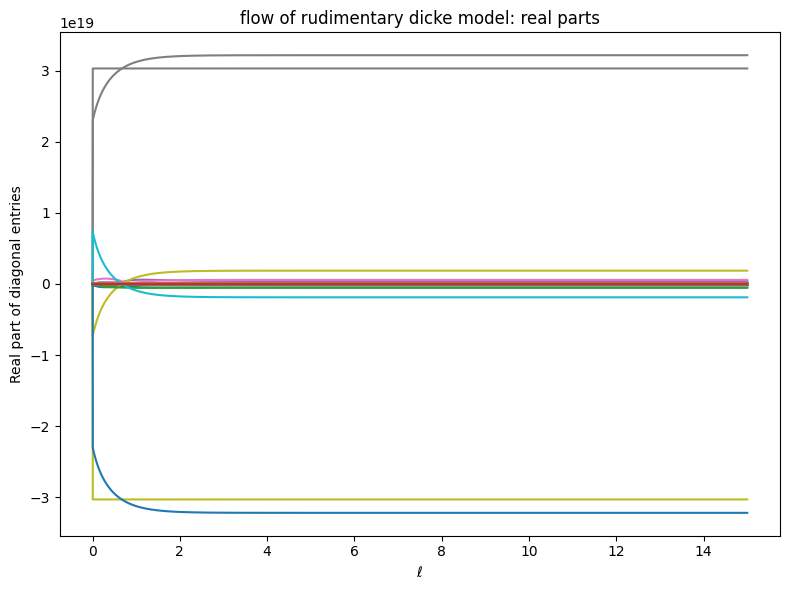

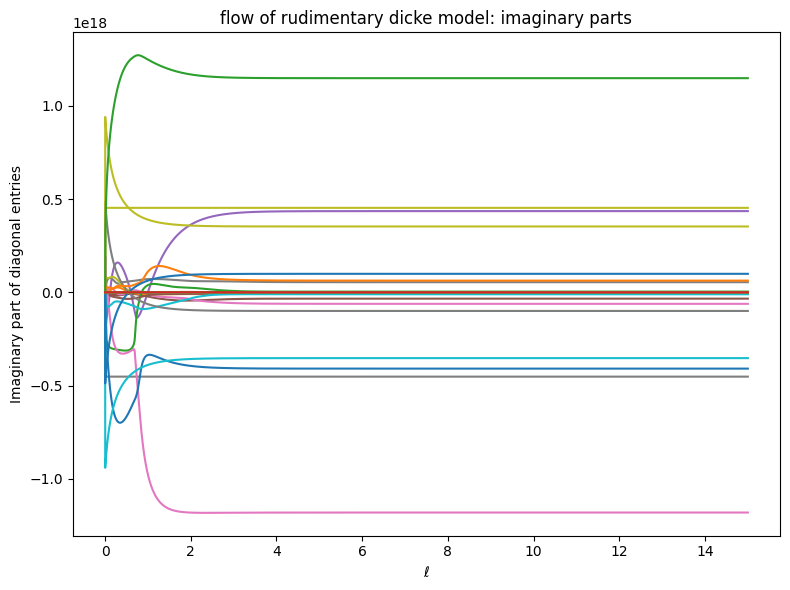

In [10]:
Super_dicke, tracker_dicke_s = solve_flow_rk4(
    L_super,
    generator="third",
    track_diagonal=True
)


plot_diagonal_flow(tracker_dicke_s, title_prefix="flow of rudimentary dicke model")